In [1]:
print("Jupyter is working!")


Jupyter is working!


In [5]:
import pandas as pd
import math


data = {
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain",
                "Rain", "Overcast", "Sunny", "Sunny", "Rain",
                "Sunny", "Overcast", "Overcast", "Rain"],

    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool",
                    "Cool", "Cool", "Mild", "Cool", "Mild",
                    "Mild", "Mild", "Hot", "Mild"],

    "Humidity": ["High", "High", "High", "High", "Normal",
                 "Normal", "Normal", "High", "Normal", "Normal",
                 "Normal", "High", "Normal", "High"],

    "Wind": ["Weak", "Strong", "Weak", "Weak", "Weak",
             "Strong", "Strong", "Weak", "Weak", "Weak",
             "Strong", "Strong", "Weak", "Strong"],

    "Play": ["No", "No", "Yes", "Yes", "Yes",
             "No", "Yes", "No", "Yes", "Yes",
             "Yes", "Yes", "Yes", "No"]
}

df = pd.DataFrame(data)


def entropy(target):
    values = target.value_counts()
    total = len(target)

    result = 0

    for count in values:
        probability = count / total
        result -= probability * math.log2(probability)

    return result

def information_gain(df, attribute, target="Play"):

    total_entropy = entropy(df[target])

    weighted_entropy = 0

    for value in df[attribute].unique():

        subset = df[df[attribute] == value]

        weight = len(subset) / len(df)

        weighted_entropy += weight * entropy(subset[target])

    return total_entropy - weighted_entropy


attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

print("Information Gain:")

for attribute in attributes:
    gain = information_gain(df, attribute)
    print(attribute, "=", round(gain, 3))


root = max(attributes, key=lambda x: information_gain(df, x))

print("\nRoot Node:", root)


print("\nDecision Tree:")

for value in df[root].unique():

    subset = df[df[root] == value]

    print(f"\n{root} = {value}")

    if len(subset["Play"].unique()) == 1:
        print("   →", subset["Play"].iloc[0])

    else:
        remaining = [a for a in attributes if a != root]

        best_attribute = max(
            remaining,
            key=lambda x: information_gain(subset, x)
        )

        print("   →", best_attribute)

        for sub_value in subset[best_attribute].unique():

            final_subset = subset[
                subset[best_attribute] == sub_value
            ]

            prediction = final_subset["Play"].mode()[0]

            print(
                f"       {best_attribute} = {sub_value}"
                f" → {prediction}"
            )

Information Gain:
Outlook = 0.247
Temperature = 0.029
Humidity = 0.152
Wind = 0.048

Root Node: Outlook

Decision Tree:

Outlook = Sunny
   → Humidity
       Humidity = High → No
       Humidity = Normal → Yes

Outlook = Overcast
   → Yes

Outlook = Rain
   → Wind
       Wind = Weak → Yes
       Wind = Strong → No


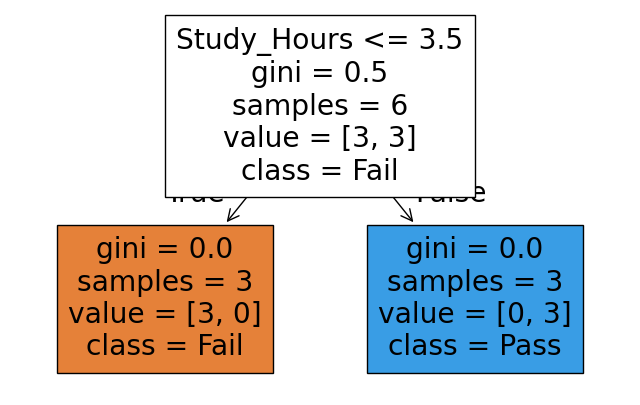

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


X = [[1], [2], [3], [4], [5], [6]]
y = [0, 0, 0, 1, 1, 1]


model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X, y)


plt.figure(figsize=(8, 5))
plot_tree(
    model,
    feature_names=["Study_Hours"],
    class_names=["Fail", "Pass"],
    filled=True
)

plt.show()

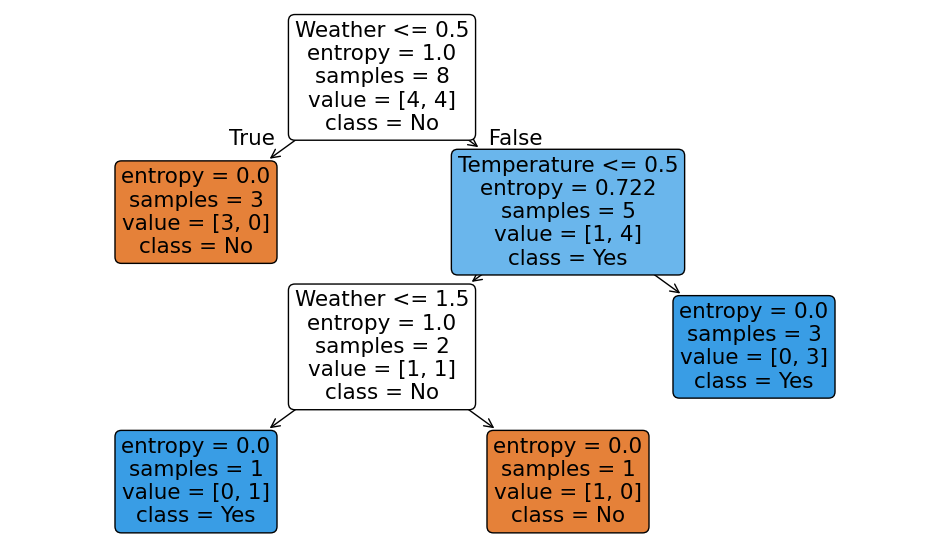

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


X = [
    [0, 1],   
    [0, 0],  
    [1, 1],
    [1, 0],  
    [2, 1],  
    [2, 0],  
    [2, 1],
    [0, 1]
]

y = [0, 0, 1, 1, 1, 0, 1, 0]

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

model.fit(X, y)


plt.figure(figsize=(12, 7))

plot_tree(
    model,
    feature_names=["Weather", "Temperature"],
    class_names=["No", "Yes"],
    filled=True,
    rounded=True
)

plt.show()